In [8]:
## Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

In [9]:
## Lendo o dataset
df = pd.read_csv("C:\\Users\\alice\\OneDrive\\Documentos\\titanic\\data\\Titanic-Dataset.csv")

In [10]:
## Primeiras explorações
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
## Verificando nulos
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
## Excluindo colunas desnecessárias para o modelo
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

In [15]:
## Preenchendo os nulos da coluna de idade com a média
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\alice\AppData\Local\Temp\ipykernel_22032\2282772270.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [16]:
## Preenchendo os nulos da coluna com a moda (variável categórica)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\alice\AppData\Local\Temp\ipykernel_22032\1422848342.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [17]:
# Passando as variáveis categóricas para números
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [18]:
## Transformando a coluna Embarked em dummies
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [19]:
## Separando features e target
X = df[['Pclass', 'Sex', 'Age', 'SibSp',	'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = df['Survived']

In [20]:
## Selecionando a amostra de treino e teste para o modelo
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42
)

In [21]:
## Criando o modelo de Árvore de Decisão
model = DecisionTreeClassifier(
    max_depth=4)

In [22]:
## Treinando o modelo
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [23]:
## Fazendo o predict do modelo
y_pred = model.predict(X_test)

In [24]:
## Calculando as métricas de acurácia
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7988826815642458


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



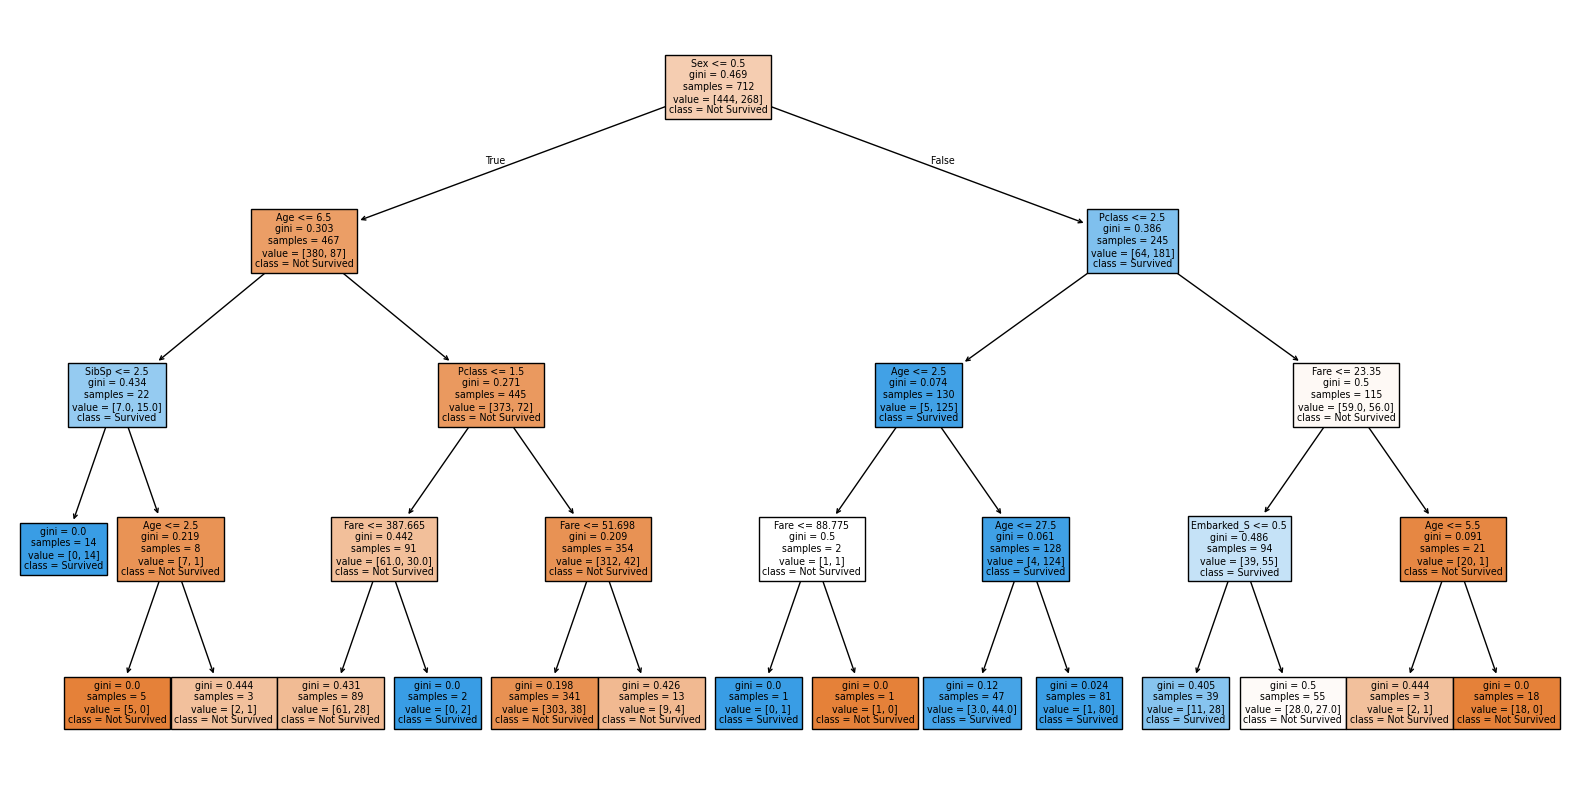

In [26]:
# Desenhar árvore de decisão treinada
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived","Survived"],
    filled=True
)

plt.show()

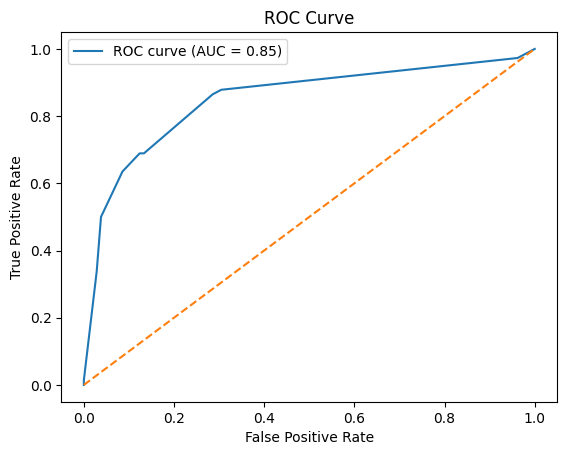

In [27]:
## Plotando a AUC
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [28]:
# Vendo a importância das features
model.fit(X_train, y_train)

importances = model.feature_importances_

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

In [30]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

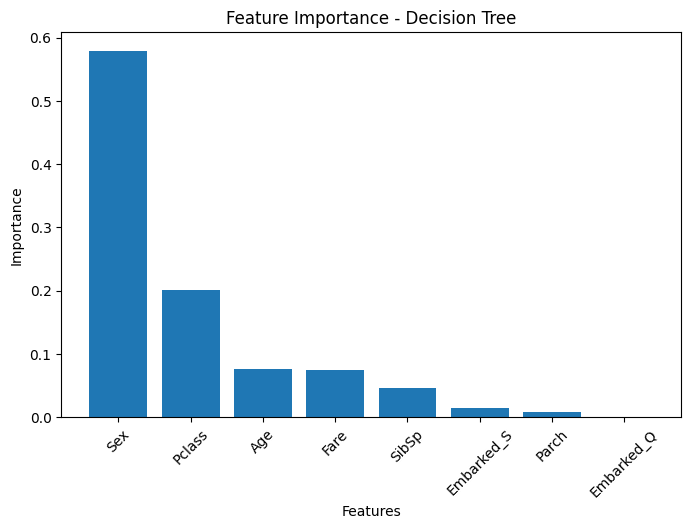

In [31]:
plt.figure(figsize=(8,5))

plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [32]:
## Fazendo cross validation do modelo de árvore
scores = cross_val_score(model, X, y, cv=5)

print(scores.mean())

0.8047642960266147


In [33]:
# Testando GridSearch
param_grid = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

In [34]:
grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

In [35]:
# Treinando o modelo de grid
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [36]:
print(grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [37]:
# Achando os melhores parâmetros do GridSearch
best_model = grid.best_estimator_

In [38]:
# Prevendo com o GridSearch
y_pred = best_model.predict(X_test)

In [39]:
# Comparando os modelos de árvore
y_pred_old = model.predict(X_test)
y_prob_old = model.predict_proba(X_test)[:,1]

In [40]:
y_pred_new = best_model.predict(X_test)
y_prob_new = best_model.predict_proba(X_test)[:,1]

In [41]:
acc_old = accuracy_score(y_test, y_pred_old)
acc_new = accuracy_score(y_test, y_pred_new)

In [42]:
auc_old = roc_auc_score(y_test, y_prob_old)
auc_new = roc_auc_score(y_test, y_prob_new)

In [43]:
print("Modelo original")
print("Accuracy:", acc_old)
print("AUC:", auc_old)

print("\nModelo otimizado (GridSearch)")
print("Accuracy:", acc_new)
print("AUC:", auc_new)

Modelo original
Accuracy: 0.7988826815642458
AUC: 0.8487129987129987

Modelo otimizado (GridSearch)
Accuracy: 0.7988826815642458
AUC: 0.8463320463320464


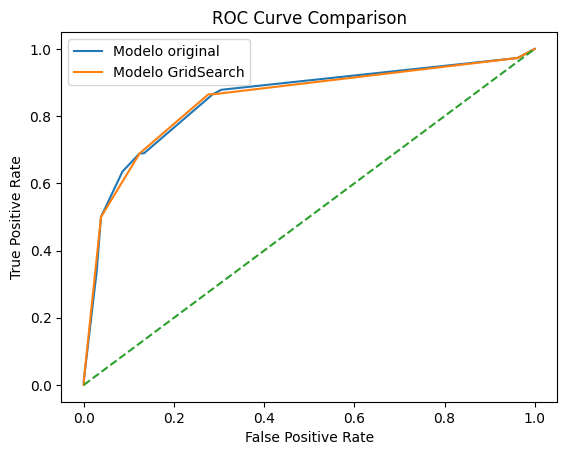

In [44]:
# auc e acurácia mostram que o modelo não melhorou
fpr_old, tpr_old, _ = roc_curve(y_test, y_prob_old)
fpr_new, tpr_new, _ = roc_curve(y_test, y_prob_new)

plt.figure()

plt.plot(fpr_old, tpr_old, label="Modelo original")
plt.plot(fpr_new, tpr_new, label="Modelo GridSearch")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

In [45]:
## Testar novos modelos, nesse caso o de RandomForest
from sklearn.ensemble import RandomForestClassifier

In [46]:
## Criação do modelo de Random Forest
rf_model = RandomForestClassifier(random_state=42)

In [47]:
#Treinamento do modelo
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
#Fazer previsões com Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [49]:
## Calcular métricas do modelo Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", acc_rf)
print("Random Forest AUC:", auc_rf)

Random Forest Accuracy: 0.8156424581005587
Random Forest AUC: 0.8868725868725869


In [50]:
## Ver importância das variáveis no Random Forest
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

      Feature  Importance
5        Fare    0.281155
1         Sex    0.263743
2         Age    0.256274
0      Pclass    0.075703
3       SibSp    0.051289
4       Parch    0.038749
7  Embarked_S    0.023923
6  Embarked_Q    0.009166


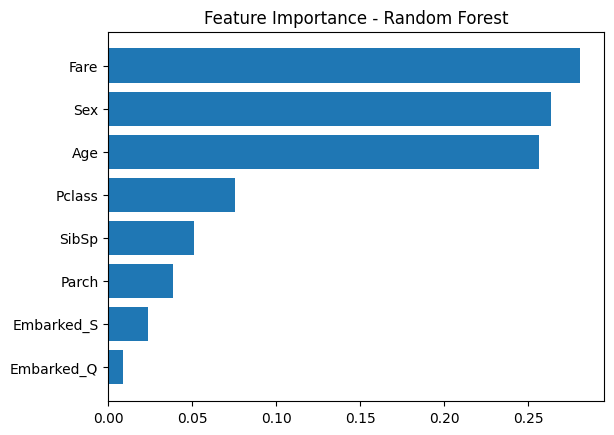

In [51]:
## Plotar a importância das variáveis no Random Forest
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [52]:
## Ver matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[90 15]
 [18 56]]


In [53]:
## Importando o modelo de regressão logística
from sklearn.linear_model import LogisticRegression

In [54]:
## Criando o modelo de Regressão logística
log_model = LogisticRegression(max_iter=1000)

In [55]:
## Treinando o modelo de Regressão logística
log_model.fit (X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
## Fazendo previsões com o modelo de Regressão logística
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [57]:
## Avaliando o modelo de regressão logística
acc_log = accuracy_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Accuracy:", acc_log)
print("Logistic Regression AUC:", auc_log)

Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression AUC: 0.8817245817245818


In [58]:
## Comparando com os outros modelos

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Decision Tree (GridSearch)",
        "Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        acc_old,
        acc_new,
        acc_rf,
        acc_log
    ],
    "AUC": [
        auc_old,
        auc_new,
        auc_rf,
        auc_log
    ]
})

print(results)

                        Model  Accuracy       AUC
0               Decision Tree  0.798883  0.848713
1  Decision Tree (GridSearch)  0.798883  0.846332
2               Random Forest  0.815642  0.886873
3         Logistic Regression  0.810056  0.881725


In [59]:
## Calculando e plotando a curva ROC dos modelos para comparação
fpr_old, tpr_old, _ = roc_curve(y_test, y_prob_old)
fpr_new, tpr_new, _ = roc_curve(y_test, y_prob_new)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

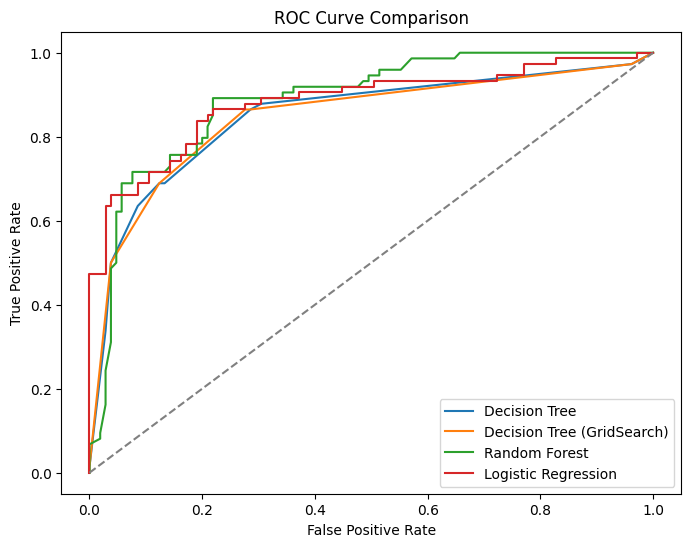

In [60]:
plt.figure(figsize=(8,6))

plt.plot(fpr_old, tpr_old, label="Decision Tree")
plt.plot(fpr_new, tpr_new, label="Decision Tree (GridSearch)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_log, tpr_log, label="Logistic Regression")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [61]:
## Fazer cross validation no melhor modelo = Random Forest

scores = cross_val_score(rf_model, X, y, cv=5)

print(scores)
print(scores.mean())

[0.78212291 0.80337079 0.83707865 0.7752809  0.83146067]
0.8058627832527776


In [62]:
## Tentar melhorar o Random Forest com GridSearch
param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [3,5,7,None],
    "min_samples_leaf": [1,3,5]
}

In [63]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [64]:
## Ver os melhores parâmetros
print(grid_rf.best_params_)

{'max_depth': 7, 'min_samples_leaf': 1, 'n_estimators': 300}


In [65]:
## Pegar o melhor modelo
best_rf = grid_rf.best_estimator_

In [66]:
## Fazer previsões
y_pred_rf_new = best_rf.predict(X_test)
y_prob_rf_new = best_rf.predict_proba(X_test)[:,1]

In [67]:
## Calcular métricas novamente
acc_rf_new = accuracy_score(y_test, y_pred_rf_new)
auc_rf_new = roc_auc_score(y_test, y_prob_rf_new)

print("Random Forest original:", acc_rf, auc_rf)
print("Random Forest otimizado:", acc_rf_new, auc_rf_new)

Random Forest original: 0.8156424581005587 0.8868725868725869
Random Forest otimizado: 0.8156424581005587 0.8875160875160875


In [68]:
## Comparar todos os modelos
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "Random Forest (Tuned)",
        "Logistic Regression"
    ],
    "Accuracy":[
        acc_old,
        acc_rf,
        acc_rf_new,
        acc_log
    ],
    "AUC":[
        auc_old,
        auc_rf,
        auc_rf_new,
        auc_log
    ]
})

print(results)

                   Model  Accuracy       AUC
0          Decision Tree  0.798883  0.848713
1          Random Forest  0.815642  0.886873
2  Random Forest (Tuned)  0.815642  0.887516
3    Logistic Regression  0.810056  0.881725


In [69]:
## Após encontrar o melhor modelo
best_rf = grid_rf.best_estimator_

In [70]:
## Salvar melhor modelo
import joblib

joblib.dump(best_rf, "titanic_model.pkl")

['titanic_model.pkl']

In [71]:
## Carregar o modelo
model = joblib.load("titanic_model.pkl")

print(model)

RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42)


In [72]:
## Fazer nova predição manual

data = pd.DataFrame({
    "Pclass":[3],
    "Sex":[0],
    "Age":[25],
    "SibSp":[0],
    "Parch":[0],
    "Fare":[7.25],
    "Embarked_Q":[0],
    "Embarked_S":[1]
})

prediction = model.predict(data)

print(prediction)

[0]
